In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def perform_eda(csv_file):


    df = pd.read_csv(csv_file)

    target = df.columns[-1]

    print("=" * 70)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 70)

    print("\nFirst 5 Rows")
    print(df.head())

    print("\nDataset Shape")
    print(df.shape)

    print("\nColumn Names")
    print(df.columns.tolist())

    print("\nTarget Column :", target)

    print("\nDataset Information")
    df.info()

    print("\nStatistical Summary")
    print(df.describe(include="all"))

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nDuplicate Rows :", df.duplicated().sum())

    numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

    print("\nNumerical Columns")
    print(numerical_cols)

    print("\nCategorical Columns")
    print(categorical_cols)

    print("\n" + "=" * 70)

    # REGRESSION

    if pd.api.types.is_numeric_dtype(df[target]):

        print("Task Type : REGRESSION")

        corr = df[numerical_cols].corr()

        plt.figure(figsize=(8,6))
        sns.heatmap(corr, annot=True, cmap="coolwarm")
        plt.title("Correlation Heatmap")
        plt.show()

        feature_corr = corr[target].drop(target).abs().sort_values(ascending=False)

        print("\nFeature Correlation Ranking")
        print(feature_corr)

        important_feature = feature_corr.index[0]

        print("\nMost Important Feature :", important_feature)
        print("Correlation :", corr.loc[important_feature, target])

        plt.figure(figsize=(7,5))
        sns.scatterplot(data=df, x=important_feature, y=target)
        plt.title(f"{important_feature} vs {target}")
        plt.show()

        plt.figure(figsize=(7,5))
        sns.histplot(df[important_feature], kde=True)
        plt.title(f"Distribution of {important_feature}")
        plt.show()

    # CLASSIFICATION

    else:

        print("Task Type : CLASSIFICATION")

        numeric_features = [col for col in numerical_cols if col != target]
        if len(numeric_features) == 0:

            print("\nNo numerical features found.")

            print("Dataset appears to be a Text Classification dataset.")

            plt.figure(figsize=(6,4))
            sns.countplot(data=df, x=target)
            plt.title(f"Distribution of {target}")
            plt.show()

            return

        feature_scores = {}

        for feature in numeric_features:

            class_means = df.groupby(target)[feature].mean()

            score = class_means.max() - class_means.min()

            feature_scores[feature] = score

        feature_scores = pd.Series(feature_scores).sort_values(ascending=False)

        print("\nFeature Separation Score")
        print(feature_scores)

        important_feature = feature_scores.index[0]

        print("\nMost Important Feature :", important_feature)

        plt.figure(figsize=(7,5))
        sns.boxplot(data=df, x=target, y=important_feature)
        plt.title(f"{important_feature} vs {target}")
        plt.show()

        plt.figure(figsize=(6,4))
        sns.countplot(data=df, x=target)
        plt.title(f"Distribution of {target}")
        plt.show()

        if len(numeric_features) <= 6:

            print("\nGenerating Pair Plot...")

            sns.pairplot(
                df[numeric_features + [target]],
                hue=target
            )

            plt.show()

        plt.figure(figsize=(7,5))
        sns.histplot(data=df, x=important_feature, hue=target,
                     kde=True, element="step")
        plt.title(f"Distribution of {important_feature}")
        plt.show()

    print("\nEDA Completed Successfully.")

    

EXPLORATORY DATA ANALYSIS

First 5 Rows
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dataset Shape
(150, 5)

Column Names
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Target Column : species

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float

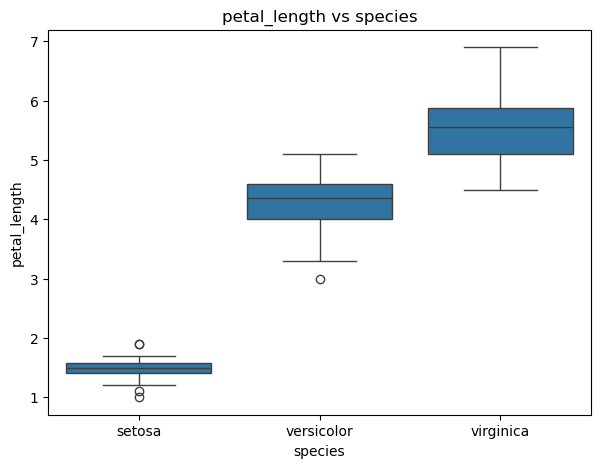

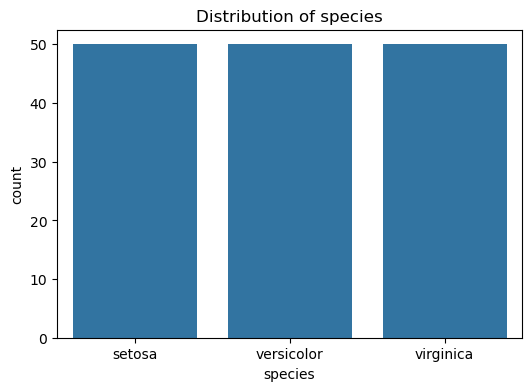


Generating Pair Plot...


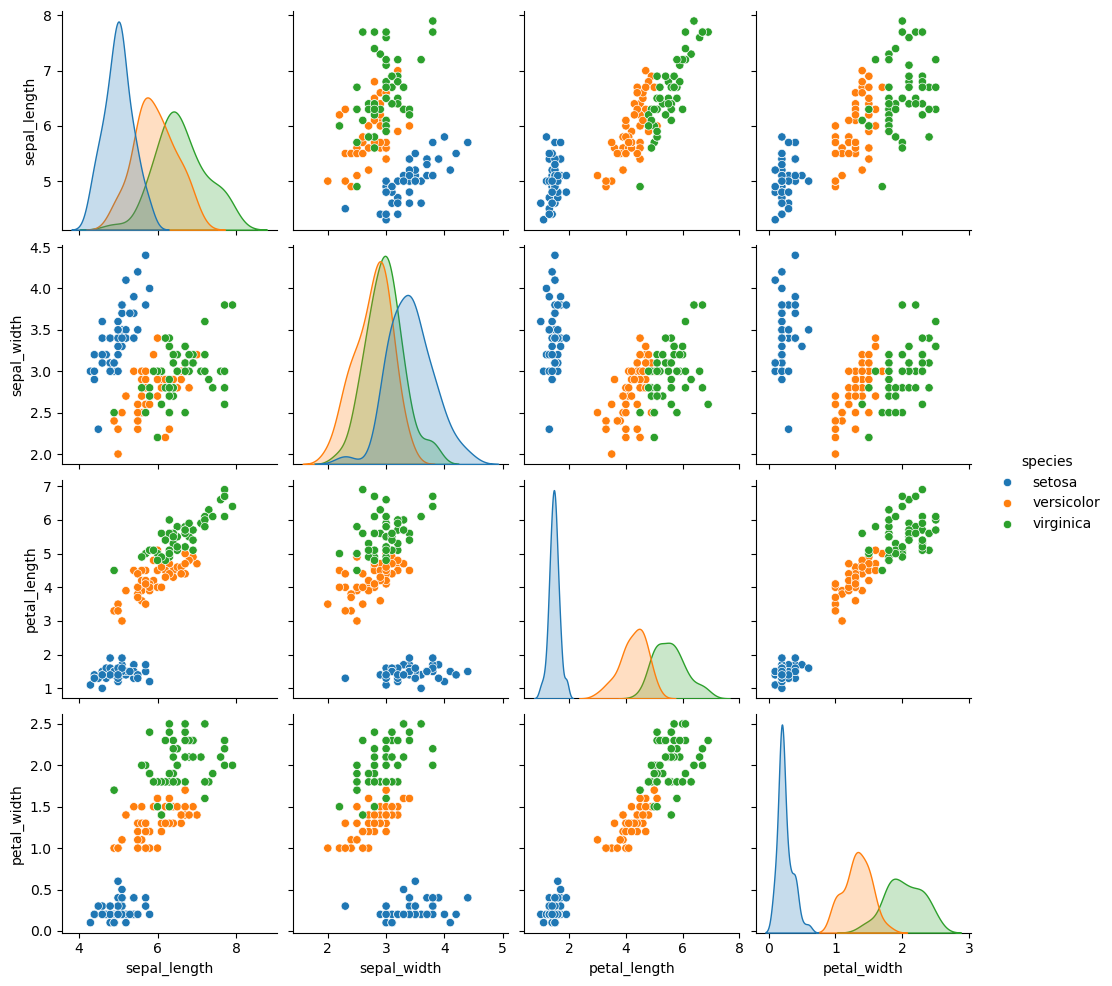

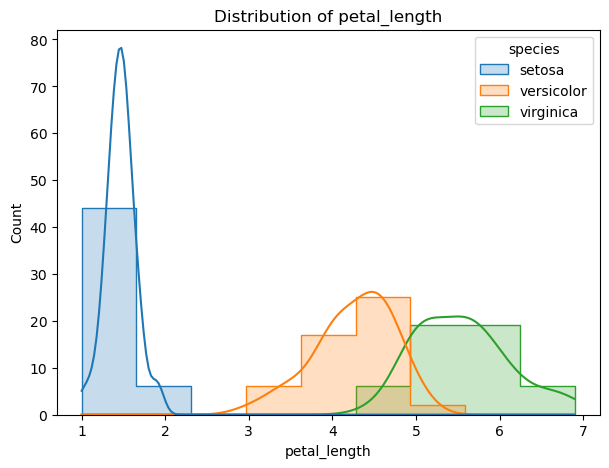


EDA Completed Successfully.


In [2]:
perform_eda("iris.csv")

EXPLORATORY DATA ANALYSIS

First 5 Rows
   age  gender marital_status education_level  annual_income  monthly_income  \
0   59    Male        Married        Master's       24240.19         2020.02   
1   72  Female        Married      Bachelor's       20172.98         1681.08   
2   49  Female         Single     High School       26181.80         2181.82   
3   35  Female         Single     High School       11873.84          989.49   
4   63   Other         Single           Other       25326.44         2110.54   

  employment_status  debt_to_income_ratio  credit_score  loan_amount  
0          Employed                 0.074           743     17173.72  
1          Employed                 0.219           531     22663.89  
2          Employed                 0.234           779      3631.36  
3          Employed                 0.264           809     14939.23  
4          Employed                 0.260           663     16551.71  

Dataset Shape
(20000, 10)

Column Names
['age', 'gen

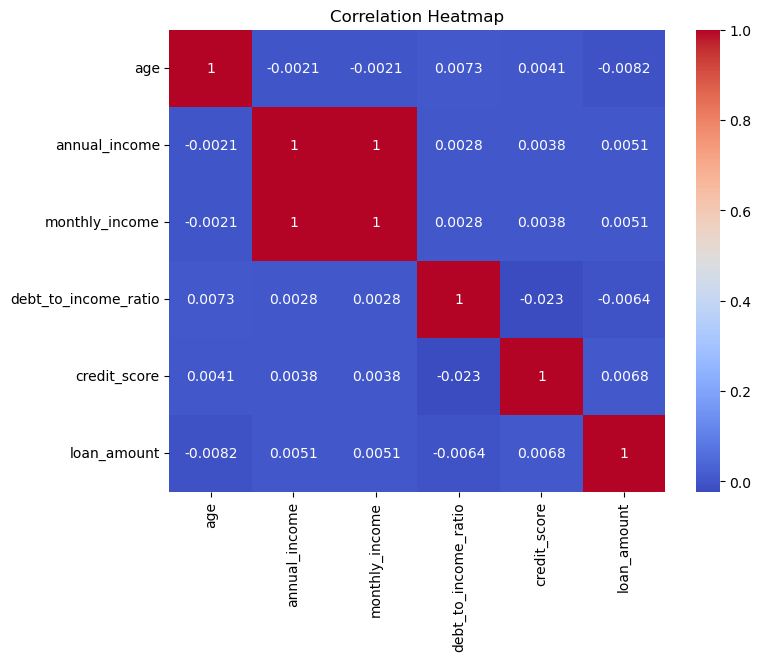


Feature Correlation Ranking
age                     0.008233
credit_score            0.006779
debt_to_income_ratio    0.006370
monthly_income          0.005094
annual_income           0.005094
Name: loan_amount, dtype: float64

Most Important Feature : age
Correlation : -0.008232938056848584


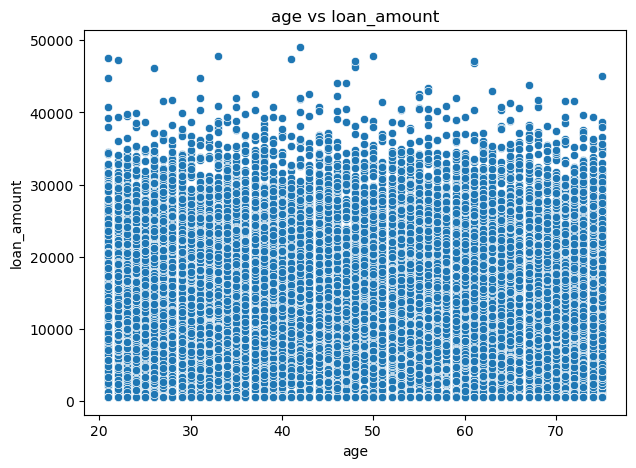

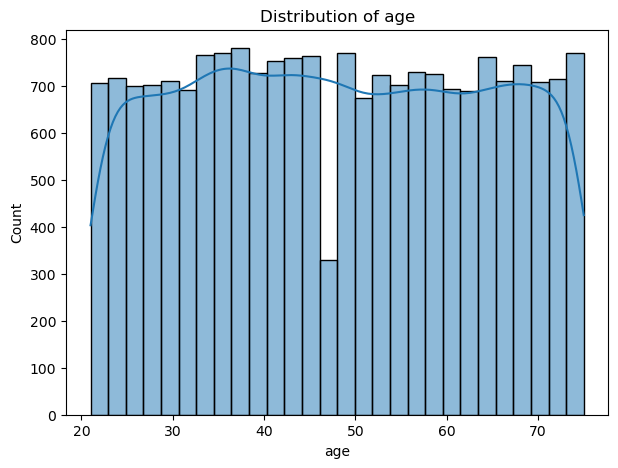


EDA Completed Successfully.


In [3]:
perform_eda("loanamt.csv")

EXPLORATORY DATA ANALYSIS

First 5 Rows
                                             Message Category
0  Go until jurong point, crazy.. Available only ...      ham
1                      Ok lar... Joking wif u oni...      ham
2  Free entry in 2 a wkly comp to win FA Cup fina...     spam
3  U dun say so early hor... U c already then say...      ham
4  Nah I don't think he goes to usf, he lives aro...      ham

Dataset Shape
(5573, 2)

Column Names
['Message', 'Category']

Target Column : Category

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Message   5573 non-null   object
 1   Category  5573 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

Statistical Summary
                       Message Category
count                     5573     5573
unique                    5158        3
top     Sorry, I'll call later      ha

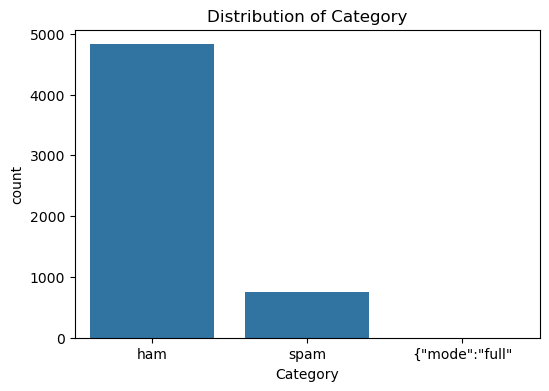

In [4]:
perform_eda("email.csv")

EXPLORATORY DATA ANALYSIS

First 5 Rows
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level diabetes  
0          6.6                  140       No  
1          6.6                   80       No  
2          5.7                  158       No  
3          5.0                  155       No  
4          4.8                  155       No  

Dataset Shape
(100000, 9)

Column Names
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Target Column : diabetes

Dataset Information
<class 'pandas.core.frame.DataFrame'

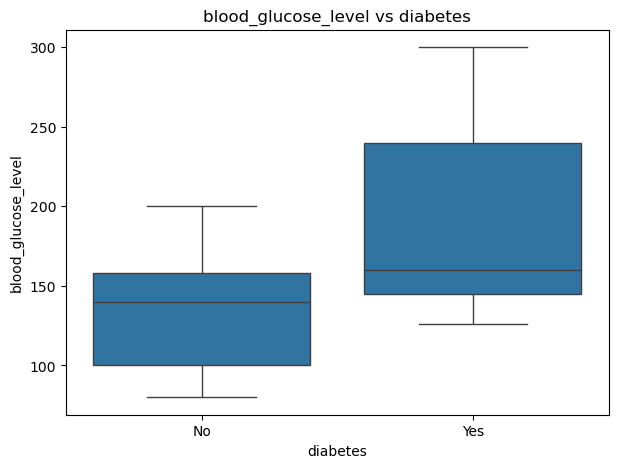

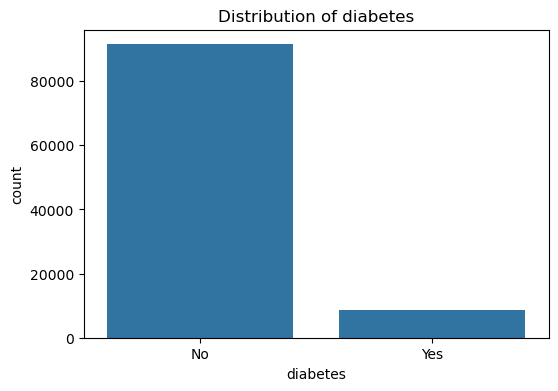


Generating Pair Plot...


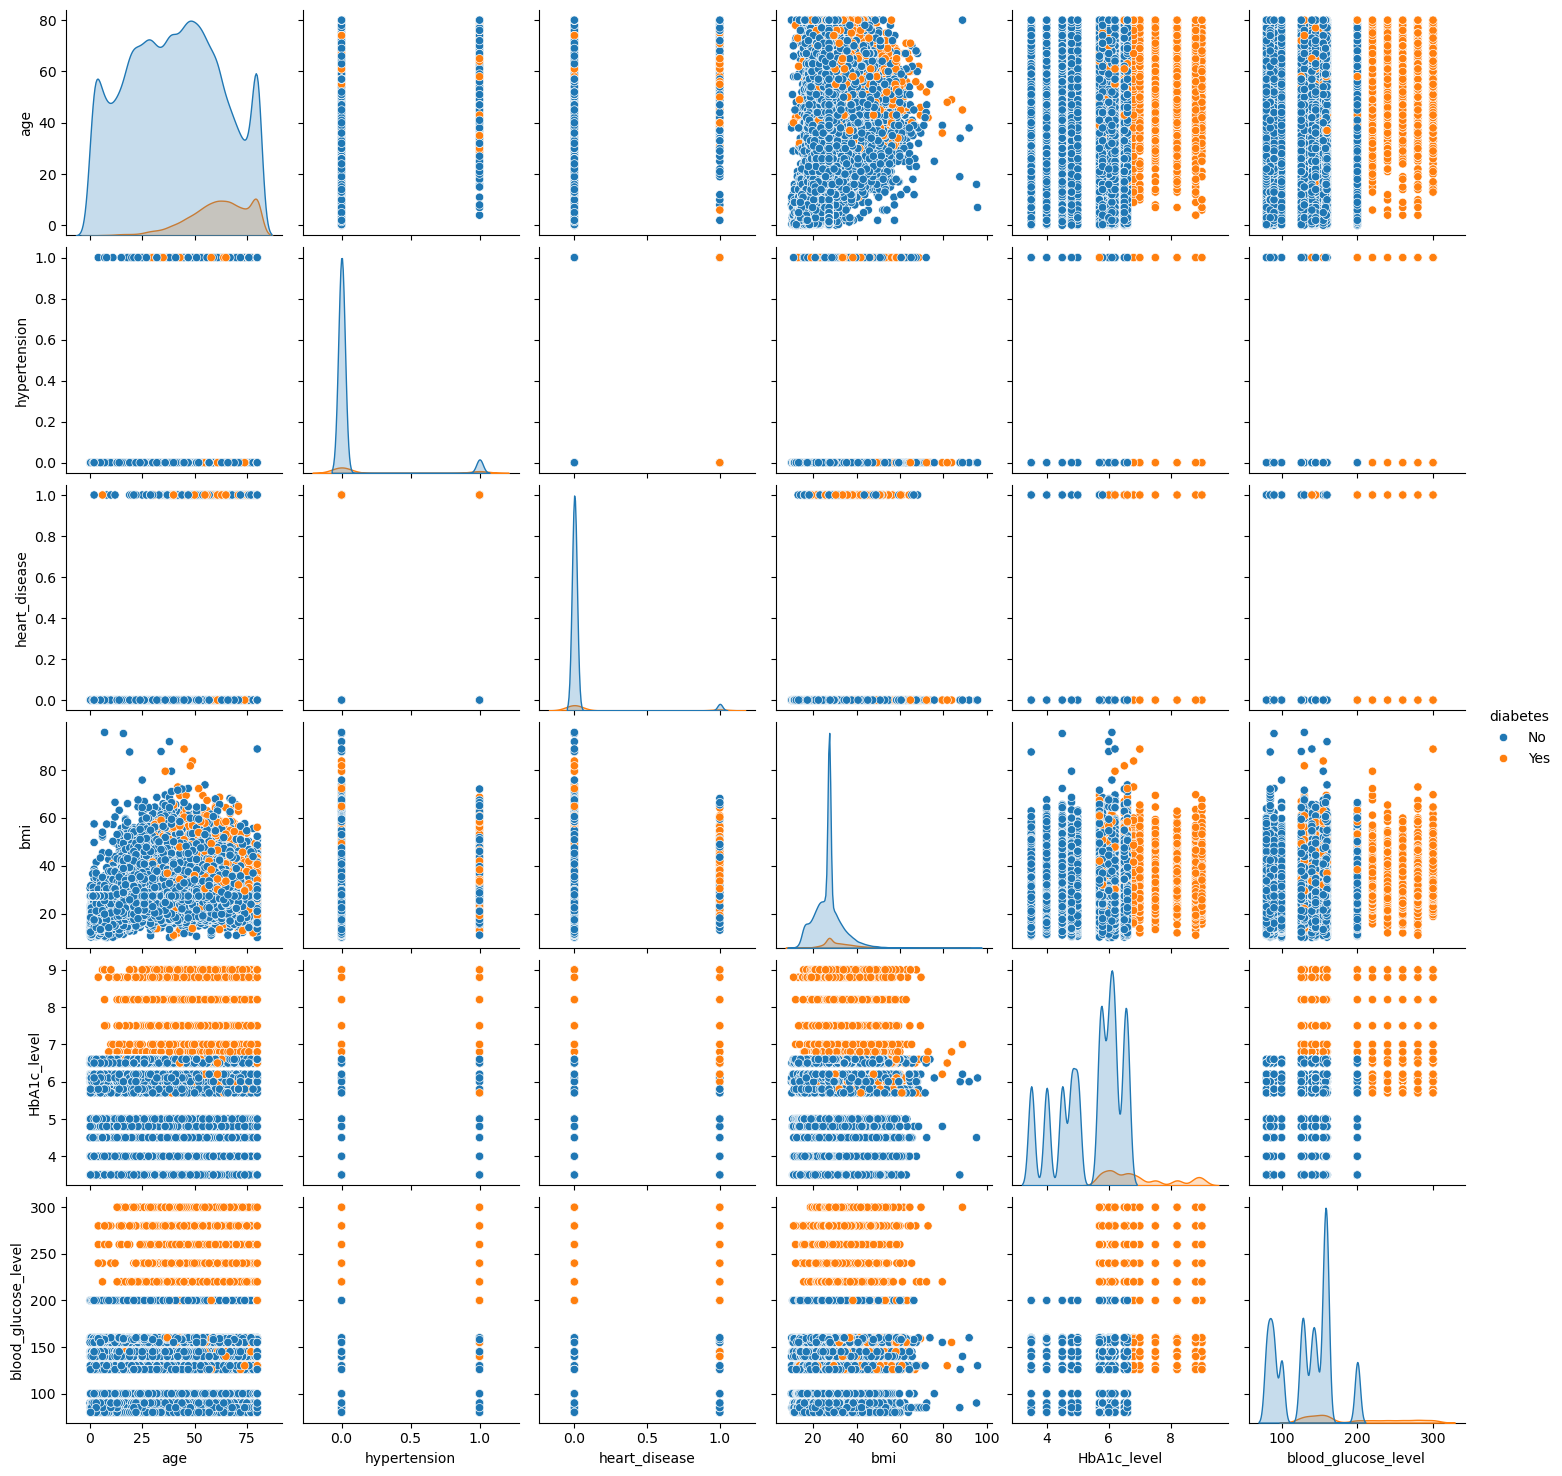

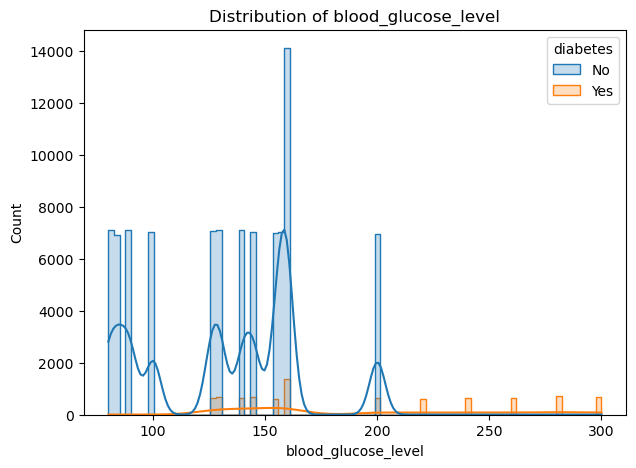


EDA Completed Successfully.


In [5]:
perform_eda("diabetes.csv")